# LABOR-3: R&S FPC1500 Spektrum-Analyzer (SCPI)

### Ziel der Uebung

Ziel dieser Übung ist das Kennenlernen der Messtechnik mit einem professionellen Spektrum-Analyzer (**Rohde & Schwarz FPC1500**).

Ein unbekannter RF-Oszillator soll hinsichtlich seiner spektralen Reinheit analysiert werden.


Der FPC1500 wird über **Ethernet** mit dem PC verbunden. Im Praktikum wird dazu ein USB/Ethernet-Adapter verwendet, dessen IP-Konfiguration zur Analyzer-IP (**`192.168.1.10`**) passen muss. Die Datenuebertragung erfolgt über das **SCPI-Protokoll**.


**Voraussetzung:** FPC1500 ist per Netzwerk erreichbar (IP und Port unten konfigurierbar).

## Kurzinfo Bedienfeld:



### FPC1500 – Bedienung (einfach erklärt)
- **Mode:**  
  Hier wählst du, *was* das Gerät sein soll:  
  **Spectrum Analyzer** (Spektrum messen) oder **Network Analyzer** (z. B. S11/S21 messen).
- **Setup:**  
  Grundeinstellungen des Geräts, z. B. Netzwerk (IP-Adresse wie `192.168.1.10`).
- **Meas:**  
  Auswahl der Messart innerhalb des aktuellen Modes.
- **Freq / Span:**  
  Hier legst du den betrachteten Frequenzbereich fest:  
  entweder über **Start/Stop** oder über **Center/Span**.
- **BW:**  
  - **RBW (Resolution Bandwidth):** bestimmt, wie fein das Spektrum aufgelöst wird.  
    Kleinere RBW = feinere Details, aber meist langsamere Messung.  
  - **VBW (Video Bandwidth):** glättet die Anzeige.  
    Kleinere VBW = ruhigeres Display, ohne die eigentliche Messphysik stark zu ändern.
- **Ampt:**  
  Einstellung des **Reference Level** (oberer Pegelrand der Anzeige in dBm).
- **Mkr / Mkr >:**  
  Marker einblenden und Marker-Funktionen nutzen, z. B.:  
  **Peak Search** (größtes Signal finden), **Marker to Center** usw.

In [6]:
import json
import socket
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from matplotlib.widgets import Slider

try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

# FPC1500: konfigurierbare Verbindung
FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 5.0
SCREENSHOT_TIMEOUT = 10.0   # HCOP und Auslesen können deutlich länger als 5 s dauern
TRACE_READ_MAX_BYTES = 256 * 1024

# Offline-Workflow: bei REPLAY=True werden Messdaten aus JSON geladen
REPLAY = False
REPLAY_FILE = Path("recordings") / "5-fpc1500_sa_replay.json"

# Screenshots lokal speichern (Laborprotokoll, persistent)
SCREENSHOT_DIR = Path("screenshots")

def scpi_query(host: str, port: int, cmd: str, max_bytes: int = 4096) -> str:
    """SCPI-Befehl senden, Antwort lesen (bis Newline oder max_bytes)."""
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SOCKET_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk
            if b"\n" in buf:
                break
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def get_trace_data(host: str, port: int):
    """Frequenzachse (Hz), Trace-Werte (dBm) und RBW (Hz) vom FPC lesen.
    Returns (freqs, amps, rbw_hz) oder None.
    """
    try:
        trace_s = scpi_query(host, port, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    except Exception:
        return None
    amps = []
    for part in trace_s.replace(",", " ").split():
        try:
            amps.append(float(part))
        except ValueError:
            continue
    if not amps:
        return None

    try:
        star_s = scpi_query(host, port, "FREQ:STAR?", max_bytes=256)
        stop_s = scpi_query(host, port, "FREQ:STOP?", max_bytes=256)
        freq_start = float(star_s.strip())
        freq_stop = float(stop_s.strip())
    except Exception:
        try:
            cent_s = scpi_query(host, port, "FREQ:CENT?", max_bytes=256)
            span_s = scpi_query(host, port, "FREQ:SPAN?", max_bytes=256)
            cent = float(cent_s.strip())
            span = float(span_s.strip())
            freq_start = cent - span / 2
            freq_stop = cent + span / 2
        except Exception:
            return None

    rbw_hz = None
    for rbw_cmd in ["BAND:RES?", "BANDwidth:RESolution?"]:
        try:
            rbw_hz = float(scpi_query(host, port, rbw_cmd, max_bytes=256).strip())
            break
        except Exception:
            continue

    n = len(amps)
    freqs = [freq_start + (freq_stop - freq_start) * i / max(1, n - 1) for i in range(n)]
    return (freqs, amps, rbw_hz)

def screenshot_save(host: str, port: int, filename: str = "screen.png") -> str | None:
    """Hardcopy auf dem Gerät auslösen und in MMEM speichern. Returns None bei Erfolg, sonst Fehlermeldung."""
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < 4096:
            try:
                chunk = s.recv(1024)
                if not chunk:
                    break
                buf += chunk
                if b"\n" in buf:
                    break
            except socket.timeout:
                break
        reply = buf.decode("utf-8", errors="replace").strip()
        if reply and "error" in reply.lower():
            return reply
        return None
    except Exception as e:
        return str(e)
    finally:
        s.close()


def save_replay_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_replay_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Replay-Datei nicht gefunden: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def screenshot_read(host: str, port: int, filename: str) -> bytes | None:
    """Datei vom Gerät (MMEM) lesen. MMEM:DATA? Antwort im IEEE 488.2-Blockformat. Returns PNG-Bytes oder None."""
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        if len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        if n_digits < 1 or n_digits > 9:
            return None
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2 : 2 + n_digits].decode())
        buf = buf[2 + n_digits :]
        while len(buf) < data_len:
            chunk = s.recv(min(65536, data_len - len(buf)))
            if not chunk:
                break
            buf += chunk
        return buf[:data_len] if len(buf) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

print("Konfiguration:", FPC_IP, "Port", FPC_PORT)
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")

Konfiguration: 192.168.1.10 Port 5555
REPLAY=False, Datei=recordings\5-fpc1500_sa_replay.json


### Verbindung testen (*IDN?)

In [7]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    reply = replay.get("idn", "REPLAY")
    print("Gerät (Replay):", reply)
else:
    reply = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
    print("Gerät:", reply if reply else "Keine Antwort (IP/Port prüfen, Gerät eingeschaltet?).")

Gerät: Rohde&Schwarz,FPC1500,1328.6660K03/102548,V1.50


### Spektrum auslesen und plotten

Trace-Daten (TRACE1) und Frequenzbereich werden per SCPI gelesen und als Betragsspektrum dargestellt.

Replay gespeichert: recordings\5-fpc1500_sa_replay.json


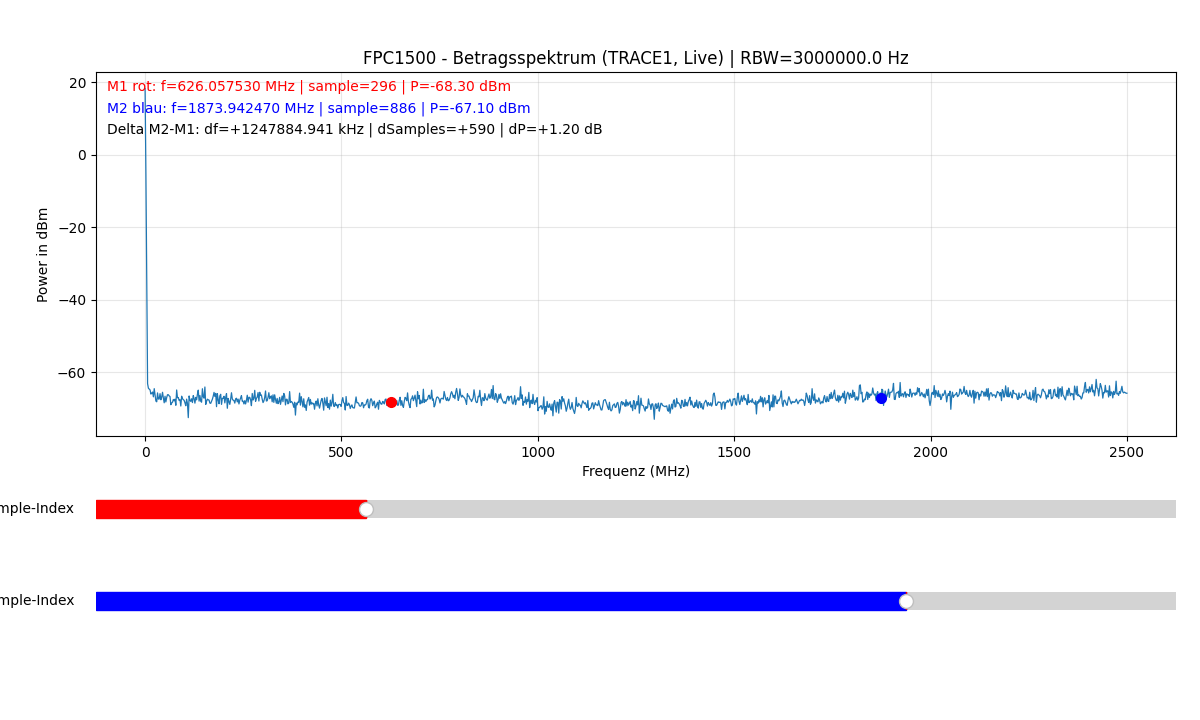

1183 Punkte, Frequenzbereich 0.0000 ... 2500.0000 MHz
RBW: 3000000.0 Hz


In [8]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    freqs = replay.get("freqs_hz", [])
    amps = replay.get("amps", [])
    rbw_hz = replay.get("rbw_hz", None)
else:
    result = get_trace_data(FPC_IP, FPC_PORT)
    if result is None:
        print("Trace-Daten konnten nicht gelesen werden.")
        freqs, amps, rbw_hz = [], [], None
    else:
        freqs, amps, rbw_hz = result
        save_replay_json(
            REPLAY_FILE,
            {
                "meta": {"type": "fpc1500_sa", "version": 2},
                "idn": reply,
                "freqs_hz": list(freqs),
                "amps": list(amps),
                "rbw_hz": rbw_hz,
            },
        )
        print("Replay gespeichert:", REPLAY_FILE)

if not freqs or not amps:
    print("Keine gueltigen Spektrumsdaten vorhanden.")
else:
    freq_hz = np.asarray(freqs, dtype=float)
    # hier sind die Leistungswerte in dBm   <----- !!!!!!!
    p_dbm = np.asarray(amps, dtype=float)
    
    freq_mhz = freq_hz / 1e6
    n = p_dbm.size

    fig = plt.figure(figsize=(12.0, 7.2), constrained_layout=False)
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 0.10, 0.10], hspace=0.38)
    ax = fig.add_subplot(gs[0, 0])
    ax_m1 = fig.add_subplot(gs[1, 0])
    ax_m2 = fig.add_subplot(gs[2, 0])
    fig.subplots_adjust(top=0.90, bottom=0.14, left=0.08, right=0.98)

    ax.plot(freq_mhz, p_dbm, color="C0", linewidth=0.9)
    ax.set_xlabel("Frequenz (MHz)")
    ax.set_ylabel("Power in dBm")
    rbw_txt = f" | RBW={rbw_hz:.1f} Hz" if (rbw_hz is not None) else " | RBW=n/a"
    title_mode = "Replay" if REPLAY else "Live"
    ax.set_title(f"FPC1500 - Betragsspektrum (TRACE1, {title_mode})" + rbw_txt)
    ax.grid(True, alpha=0.3)

    idx1_0 = int(round(0.25 * (n - 1)))
    idx2_0 = int(round(0.75 * (n - 1)))

    m1, = ax.plot([freq_mhz[idx1_0]], [p_dbm[idx1_0]], "o", color="red", ms=7)
    m2, = ax.plot([freq_mhz[idx2_0]], [p_dbm[idx2_0]], "o", color="blue", ms=7)

    info_m1 = ax.text(0.01, 0.98, "", color="red", fontsize=10, ha="left", va="top", transform=ax.transAxes)
    info_m2 = ax.text(0.01, 0.92, "", color="blue", fontsize=10, ha="left", va="top", transform=ax.transAxes)
    info_delta = ax.text(0.01, 0.86, "", color="black", fontsize=10, ha="left", va="top", transform=ax.transAxes)
    info_power = ax.text(0.01, 0.80, "", color="0.2", fontsize=10, ha="left", va="top", transform=ax.transAxes)

    # Platzhalter: spektrale Gesamtleistung [dBm] aus den Werten vom numpy-array "p_dbm" im Marker-Intervall (in update_markers berechnen)
    spectral_power_dbm = None

    s1 = Slider(
        ax=ax_m1,
        label="Marker 1 (rot) - Sample-Index",
        valmin=0,
        valmax=n - 1,
        valinit=idx1_0,
        valstep=1,
        color="red",
    )
    s2 = Slider(
        ax=ax_m2,
        label="Marker 2 (blau) - Sample-Index",
        valmin=0,
        valmax=n - 1,
        valinit=idx2_0,
        valstep=1,
        color="blue",
    )
    ax_m1.set_facecolor("#f7f7f7")
    ax_m2.set_facecolor("#f7f7f7")

    def update_markers(_=None):
        global spectral_power_dbm
        i1 = int(s1.val)
        i2 = int(s2.val)

        m1.set_data([freq_mhz[i1]], [p_dbm[i1]])
        m2.set_data([freq_mhz[i2]], [p_dbm[i2]])

        df_hz = freq_hz[i2] - freq_hz[i1]
        df_khz = df_hz / 1000.0
        di = i2 - i1
        dp_db = p_dbm[i2] - p_dbm[i1]

        info_m1.set_text(
            f"M1 rot: f={freq_mhz[i1]:.6f} MHz | sample={i1} | P={p_dbm[i1]:.2f} dBm"
        )
        info_m2.set_text(
            f"M2 blau: f={freq_mhz[i2]:.6f} MHz | sample={i2} | P={p_dbm[i2]:.2f} dBm"
        )
        info_delta.set_text(
            f"Delta M2-M1: df={df_khz:+.3f} kHz | dSamples={di:+d} | dP={dp_db:+.2f} dB"
        )

        i_lo, i_hi = sorted((i1, i2))


        fig.canvas.draw_idle()

    s1.on_changed(update_markers)
    s2.on_changed(update_markers)
    update_markers()

    plt.show()

    print(f"{n} Punkte, Frequenzbereich {freq_mhz[0]:.4f} ... {freq_mhz[-1]:.4f} MHz")
    if rbw_hz is not None:
        print(f"RBW: {rbw_hz:.1f} Hz")

## Aufgabe: Spektrale Gesamtleistung des Oszillator-Signals, Klirrfaktor und SNR (Oszillatorsignal versus geschätztem Noise-Floor).

**Bestimme die gesamte spektrale Leistung des Oszillators.**

- **Ermittle dessen Klirrfaktor.**

- **Schätze die Lesitungsdichte des Noise-Floors (Durchschnittswert)**

- **Berechne daraus das $C/N_0$**

Erkläre den beabsichtigten Rechengang als **Kommentar** 




In [9]:
# Die Aufgabe ist HIER umzusetzen.
pass

### Screenshot vom Gerät lesen und anzeigen

Hardcopy (PNG) auf dem FPC auslösen, dann Datei per MMEM:DATA? lesen und hier anzeigen.

### ACHTUNG:
Die Screenshot-Funktion dauert bis zu 10 Sekunden ! Solange wird auch die Zelle ausgeführt, was aus dem [*] -Symbol links der Zelle ersichtlich ist.


Gespeichert (Laborprotokoll): C:\_Git\KT-workspace\lab_suite\labs\05_01_LABOR-6-solution\screenshots\fpc1500_sa_screenshot.png


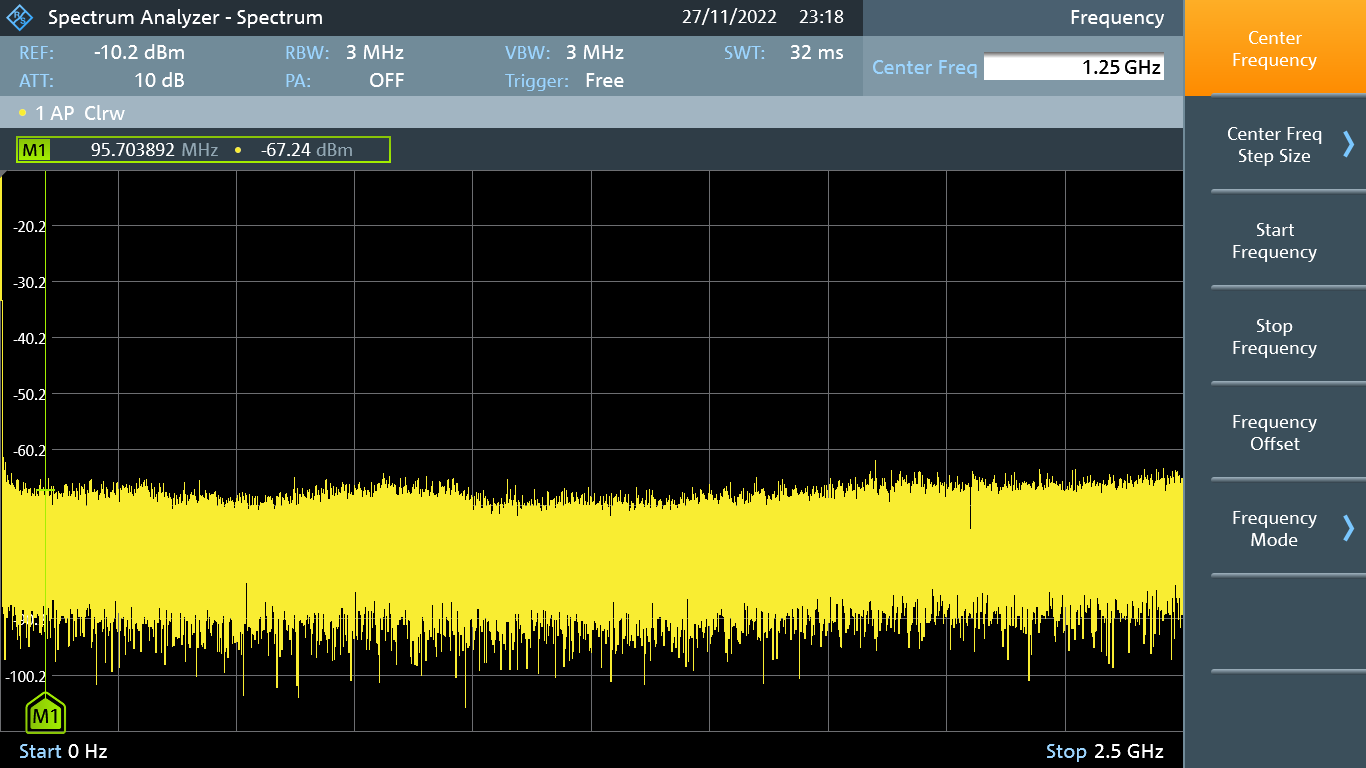

Replay aktualisiert mit screenshot_path: recordings\fpc1500_sa_replay.json


In [5]:
SCREENSHOT_FILENAME = "screen.png"
SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    shot_path_str = replay.get("screenshot_path", "")
    shot_path = Path(shot_path_str) if shot_path_str else None

    if shot_path and shot_path.exists():
        print("Replay-Screenshot geladen:", shot_path)
        display(Image(filename=str(shot_path)))
    else:
        print("REPLAY=True: Kein gueltiger screenshot_path in Replay-Datei vorhanden.")
        if shot_path_str:
            print("Gespeicherter Pfad (nicht gefunden):", shot_path_str)
else:
    err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if err:
        print("Screenshot (HCOP) Fehler:", err)
    else:
        png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
        if png_bytes:
            path = SCREENSHOT_DIR / f"{REPLAY_FILE.stem.replace('_replay', '')}_screenshot.png"
            path.write_bytes(png_bytes)
            print("Gespeichert (Laborprotokoll):", path.resolve())
            display(Image(data=png_bytes))

            # Screenshot-Verweis im Replay-JSON ablegen
            try:
                replay = load_replay_json(REPLAY_FILE) if REPLAY_FILE.exists() else {}
                replay["screenshot_path"] = str(path)
                save_replay_json(REPLAY_FILE, replay)
                print("Replay aktualisiert mit screenshot_path:", REPLAY_FILE)
            except Exception as ex:
                print("Hinweis: screenshot_path konnte nicht im Replay gespeichert werden:", ex)
        else:
            print("Screenshot auf Geraet gespeichert; Anzeige (MMEM:DATA?) nicht moeglich oder nicht unterstuetzt.")


**Notebook exportieren (Laborprotokoll):** Über *File → Save and Export Notebook As…* bzw. **nbconvert** exportierbar als **HTML** (mit Ausgaben/Bildern), **PDF** oder **LaTeX**. Screenshots liegen dauerhaft im Ordner `screenshots/`.

In [6]:
# Platzhalter für eventuelle Kommentare